# Online Retail Data Analysis

## Business Objective
The goal of this project is to analyze an e-commerce retail dataset to understand sales trends, customer behavior, product performance, and geographic patterns. The analysis aims to generate actionable business insights.


## Import Libraries

In [69]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [70]:
df = pd.read_csv(r"D:\\online-retail-data-analysis\Data\\online_retail_II.csv")
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1048570,580501,23284,DOORMAT KEEP CALM AND COME IN,2,04-12-2011 13:00,8.25,14546.0,United Kingdom
1048571,580501,22507,MEMO BOARD RETROSPOT DESIGN,3,04-12-2011 13:00,4.95,14546.0,United Kingdom
1048572,580502,22469,HEART OF WICKER SMALL,3,04-12-2011 13:15,1.65,16931.0,United Kingdom
1048573,580502,23489,VINTAGE BELLS GARLAND,2,04-12-2011 13:15,2.89,16931.0,United Kingdom


## Initial Data Inspection


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1048575 non-null  object 
 1   StockCode    1048575 non-null  object 
 2   Description  1044203 non-null  object 
 3   Quantity     1048575 non-null  int64  
 4   InvoiceDate  1048575 non-null  object 
 5   Price        1048575 non-null  float64
 6   Customer ID  811893 non-null   float64
 7   Country      1048575 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 64.0+ MB


In [72]:
df.describe()

,Quantity,Price,Customer ID
count,1.048575e+06,1.048575e+06,811893.000000
mean,9.957525e+00,4.627346e+00,15324.712265
std,1.335187e+02,1.228024e+02,1697.033034
min,-7.421500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13971.000000
50%,3.000000e+00,2.100000e+00,15260.000000
75%,1.000000e+01,4.150000e+00,16795.000000
max,7.421500e+04,3.897000e+04,18287.000000


In [73]:
df.shape

(1048575, 8)

In [74]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

## Data Quality Checks


In [75]:
df.isna().sum()

Invoice             0
StockCode           0
Description      4372
Quantity            0
InvoiceDate         0
Price               0
Customer ID    236682
Country             0
dtype: int64

In [76]:
df.duplicated().sum()

np.int64(34150)

In [77]:
#checking the cancellled orders
df["Invoice"].str.startswith("C").sum()

np.int64(19261)

In [78]:
# checking for the negative quantity
(df["Quantity"]<0).sum()

np.int64(22697)

In [79]:
# checking for unique customers
df["Invoice"].nunique()

52961

In [80]:
# checking counts of top 10 country
df["Country"].value_counts().head(10)

Country
United Kingdom    963819
EIRE               17581
Germany            17327
France             14100
Netherlands         5054
Spain               3740
Switzerland         3189
Belgium             3056
Portugal            2566
Australia           1913
Name: count, dtype: int64

In [81]:
#cleaning process first by removing the duplicates rows
df=df.drop_duplicates()
df.duplicated().sum()


np.int64(0)

In [82]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

## Data Cleaning

In this section, we clean the dataset by:
- Removing duplicates
- Handling missing values
- Removing cancelled invoices
- Filtering invalid quantities and prices

In [83]:
#converting the dtype of Invoice date from object to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"],dayfirst=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_28380\161193007.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"],dayfirst=True)


In [84]:
#checking for the cancelled row present in df
df["Invoice"].str.startswith("C").sum()

np.int64(18872)

In [85]:
# Calculating the cancellation rate 
Cancellation_rate = (df["Invoice"].str.startswith("C").sum()/df["Invoice"].shape)*100
Cancellation_rate

array([1.86036425])

In [86]:
# Creating new dataframe for storing the cleaned date free of cancelled minus quantity and price 
sales_date = df[~df["Invoice"].str.startswith("C")]

In [87]:
# checking negative quantity
(sales_date["Quantity"]<0).sum()

np.int64(3373)

In [88]:
# checking negative price 
(sales_date["Price"]<0).sum()

np.int64(5)

In [89]:
# storing the minus quantity and minus price 
Minus_Quanity = sales_date[sales_date["Quantity"]<0]
Minus_Price = sales_date[sales_date["Price"]<0]


In [90]:
# Removing the negative quantity and negative price from the sales_date
sales_date = sales_date[(sales_date["Quantity"]>0)& (sales_date["Price"]>0)]

### Feature Engineering

In [91]:
# creating the new columns named Revenue
sales_date["Revenue"] = sales_date["Quantity"]*sales_date["Price"]


In [92]:
# creating the new columns from the invoice date year and month
sales_date["Year"] = sales_date["InvoiceDate"].dt.year
sales_date["Month"] = sales_date["InvoiceDate"].dt.month


In [93]:
# Checking for the total revenue 
sales_date["Revenue"].sum()

np.float64(19958370.878)

## Exploratory Data Analysis (EDA)

We analyze:
- Sales trends
- Product performance
- Customer behavior
- Geographic distribution

### Monthly Revenue Analysis

### Insight

- Revenue shows a clear increasing trend toward the end of the year.
- November records the highest sales, likely due to seasonal demand.
- This indicates strong holiday-driven purchasing behavior.

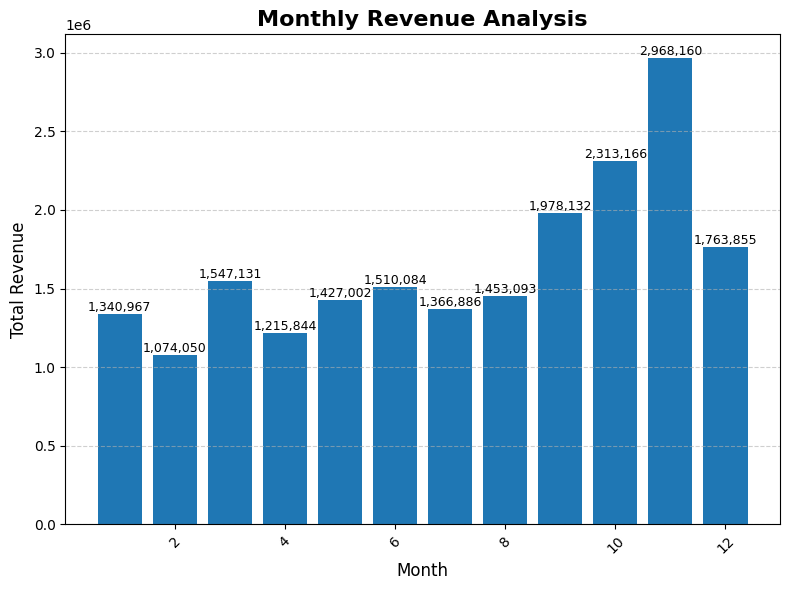

In [94]:
Monthly_Analysis = sales_date.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(8,6))

bars = plt.bar(Monthly_Analysis.index, Monthly_Analysis)

plt.title("Monthly Revenue Analysis", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f'{yval:,.0f}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("monthly_revenue.png",bbox_inches="tight")
plt.show()


In [95]:
# creating the columns for the time series 
sales_date["Date"] = pd.to_datetime(sales_date[["Year","Month"]].assign(day=1))

### Revenue Trend Over Time

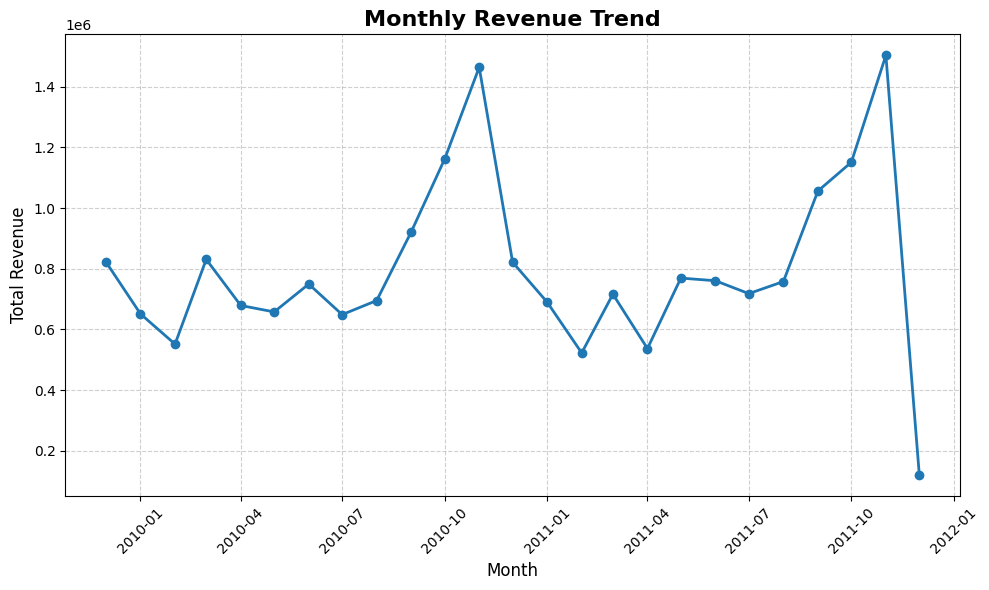

In [96]:
# creating the year-month revenue analysis and creating the chart accordinglly
Total_year_revenue= sales_date.groupby("Date")["Revenue"].sum()
plt.figure(figsize=(10,6))

plt.plot(
    Total_year_revenue.index,
    Total_year_revenue.values,
    marker="o",
    linewidth=2,
)

plt.title("Monthly Revenue Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("Revenue_trend_over_time.png",bbox_inches="tight")
plt.show()


### Top Products by Revenue

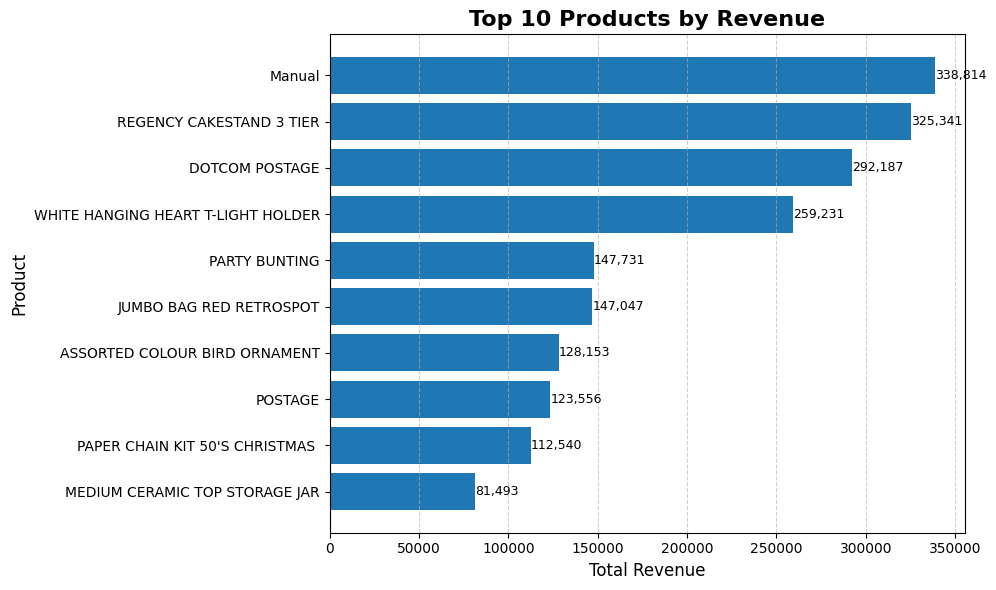

In [97]:
# Finding the Top 10 products by revenue
Top_10_products_by_Revenue = (
    sales_date.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    Top_10_products_by_Revenue.index,
    Top_10_products_by_Revenue.values
)

plt.title("Top 10 Products by Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Total Revenue", fontsize=12)
plt.ylabel("Product", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.6)

# add revenue labels
for bar in bars:
    xval = bar.get_width()
    plt.text(
        xval,
        bar.get_y() + bar.get_height()/2,
        f"{xval:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("top_products_revenue.png",bbox_inches="tight")
plt.show()


### Product Pareto Analysis

### Insight

- A small number of products generate a large portion of revenue.
- This indicates a Pareto distribution in product sales.
- The business should focus on maintaining stock for high-performing products.

In [98]:
# Pareto analysis finding the 20 products or more products that generate the 80% revenue
Product_pareto_analysis = (
    sales_date.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    )


In [99]:
# reseting the index to create the columns
Product_pareto_analysis = Product_pareto_analysis.reset_index()

In [100]:
# Droping eh index which is created after reseting the index
Product_pareto_analysis.head()

,Description,Revenue
0,Manual,338813.83
1,REGENCY CAKESTAND 3 TIER,325341.37
2,DOTCOM POSTAGE,292186.57
3,WHITE HANGING HEART T-LIGHT HOLDER,259231.33
4,PARTY BUNTING,147731.34


In [101]:
# Adding the cumulative Revenue in the product_pareto_analysis by using the cumsum()
Product_pareto_analysis["Cumulative_Revenue"] = Product_pareto_analysis["Revenue"].cumsum()
# Adding the cumalative % by cumulative_revenue/revenue.sum()
Product_pareto_analysis["Cumulative_%"] = (
    Product_pareto_analysis["Cumulative_Revenue"]/
    (Product_pareto_analysis["Revenue"]).sum()
    )*100
Product_pareto_analysis.head()

,Description,Revenue,Cumulative_Revenue,Cumulative_%
0,Manual,338813.83,338813.83,1.697603
1,REGENCY CAKESTAND 3 TIER,325341.37,664155.20,3.327702
2,DOTCOM POSTAGE,292186.57,956341.77,4.791683
3,WHITE HANGING HEART T-LIGHT HOLDER,259231.33,1215573.10,6.090543
4,PARTY BUNTING,147731.34,1363304.44,6.830740


In [102]:
# checking which products generates the 80 % of revenue
Product_pareto_analysis[Product_pareto_analysis["Cumulative_%"]<=80]

,Description,Revenue,Cumulative_Revenue,Cumulative_%
0,Manual,338813.83,338813.83,1.697603
1,REGENCY CAKESTAND 3 TIER,325341.37,664155.20,3.327702
2,DOTCOM POSTAGE,292186.57,956341.77,4.791683
3,WHITE HANGING HEART T-LIGHT HOLDER,259231.33,1215573.10,6.090543
4,PARTY BUNTING,147731.34,1363304.44,6.830740
...,...,...,...,...
1146,12 IVORY ROSE PEG PLACE SETTINGS,3842.63,15950491.26,79.918804
1147,BISCUIT TIN VINTAGE GREEN,3838.47,15954329.73,79.938036
1148,SET/4 BLUE FLOWER CANDLES IN BOWL,3837.30,15958167.03,79.957263
1149,MULTICOLOUR SPRING FLOWER MUG,3836.03,15962003.06,79.976483


In [103]:
# Adding  the rank system so that it help to 
Product_pareto_analysis["Rank"] = Product_pareto_analysis["Revenue"].rank(ascending=False).astype(int)

In [104]:
# droping the index column 
Product_pareto_analysis.head()

,Description,Revenue,Cumulative_Revenue,Cumulative_%,Rank
0,Manual,338813.83,338813.83,1.697603,1
1,REGENCY CAKESTAND 3 TIER,325341.37,664155.20,3.327702,2
2,DOTCOM POSTAGE,292186.57,956341.77,4.791683,3
3,WHITE HANGING HEART T-LIGHT HOLDER,259231.33,1215573.10,6.090543,4
4,PARTY BUNTING,147731.34,1363304.44,6.830740,5


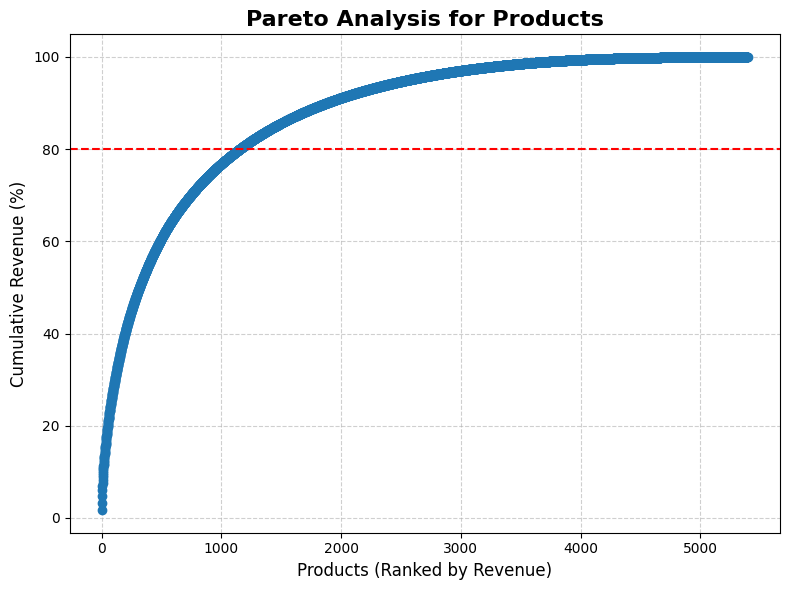

In [105]:
# creating the pareto chart using the cumulative % and rank
plt.figure(figsize=(8,6))

plt.plot(
    Product_pareto_analysis["Rank"],
    Product_pareto_analysis["Cumulative_%"],
    marker="o",
    linewidth=1
)

plt.title("Pareto Analysis for Products", fontsize=16, fontweight="bold")
plt.xlabel("Products (Ranked by Revenue)", fontsize=12)
plt.ylabel("Cumulative Revenue (%)", fontsize=12)

plt.axhline(y=80, color="red",linestyle="--")   # 80% Pareto reference line
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("Product_pareto.png",bbox_inches="tight")
plt.show()


In [106]:
#
Product_pareto_analysis[Product_pareto_analysis["Cumulative_%"]<=80]["Rank"].max()

np.int64(1151)

### Country-wise Revenue Analysis

### Insight

- The United Kingdom contributes the majority of revenue.
- This shows heavy dependence on a single geographic market.
- Expanding international markets could reduce business risk.

In [107]:
# Creating the data frame to find top 10 country wise revenue
Top_10_country_wise_revenue=(
    sales_date.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10))


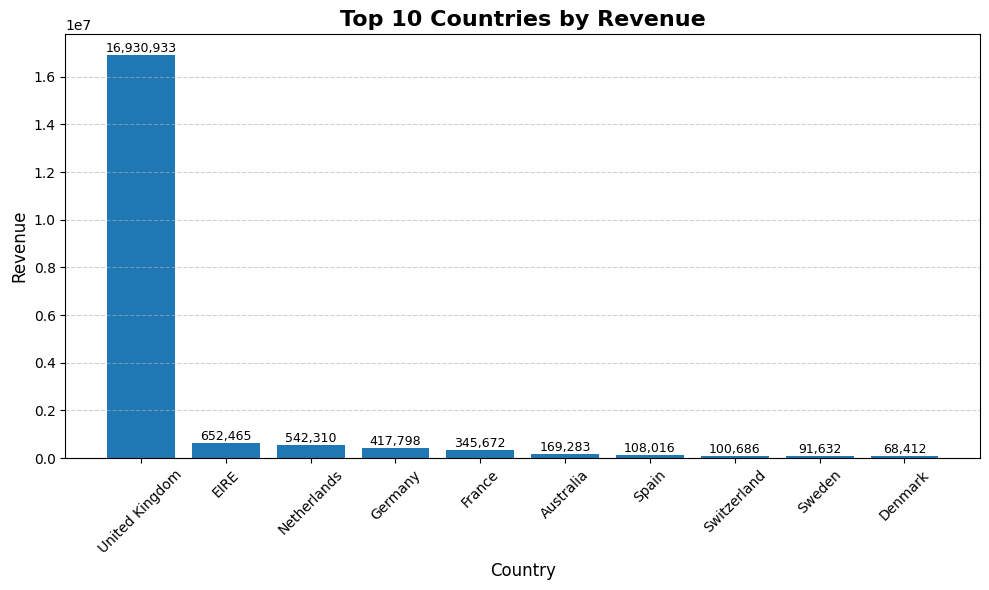

In [108]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    Top_10_country_wise_revenue.index,
    Top_10_country_wise_revenue.values
)

plt.title("Top 10 Countries by Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Country", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Add revenue labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        f"{yval:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("country_revenue.png",bbox_inches="tight")
plt.show()


In [109]:
# creating the dataframe for country wise orders to find the aov
Country_wise_orders = (
    sales_date.groupby("Country")["Invoice"]
    .nunique()
    .sort_values(ascending=False)   
)


### Average Order Value by Country

In [110]:
# checking the average order by country 
Country_wise_revenue = (
    sales_date.groupby('Country')["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
Country_wise_revenue.head()

Country
United Kingdom    1.693093e+07
EIRE              6.524653e+05
Netherlands       5.423101e+05
Germany           4.177984e+05
France            3.456718e+05
Name: Revenue, dtype: float64

In [111]:
# concating the country revenue and country order fro the country analysis 
Country_Analysis = pd.concat([Country_wise_revenue,Country_wise_orders],axis=1)
Country_Analysis.head()

,Revenue,Invoice
Country,,
United Kingdom,1.693093e+07,36047
EIRE,6.524653e+05,619
Netherlands,5.423101e+05,225
Germany,4.177984e+05,775
France,3.456718e+05,609


In [112]:
# reseting the index of the country analysis
Country_Analysis=Country_Analysis.reset_index()

In [113]:
# creating the new column for the "Average_order_value" to check average order by revenue and order
Country_Analysis["Average_Order_value"] = Country_Analysis["Revenue"]/Country_Analysis["Invoice"]

In [114]:
# Sorting the Country Analysis by sorting the Average order value ascending 
Country_Analysis = Country_Analysis.sort_values("Average_Order_value",ascending=False)

In [115]:
#  checking the average order value from the country which have order from the countries
Average_order_30 = Country_Analysis[Country_Analysis["Invoice"]>=30]

### Order Quantity Distribution

### Insight

- Most orders contain between 1 and 5 items.
- This indicates retail purchasing behavior rather than wholesale.
- Bulk purchases are rare but contribute significantly to revenue.

In [116]:
# Finding the order size disturibution 
Retail_orders = sales_date[sales_date["Quantity"]<100]


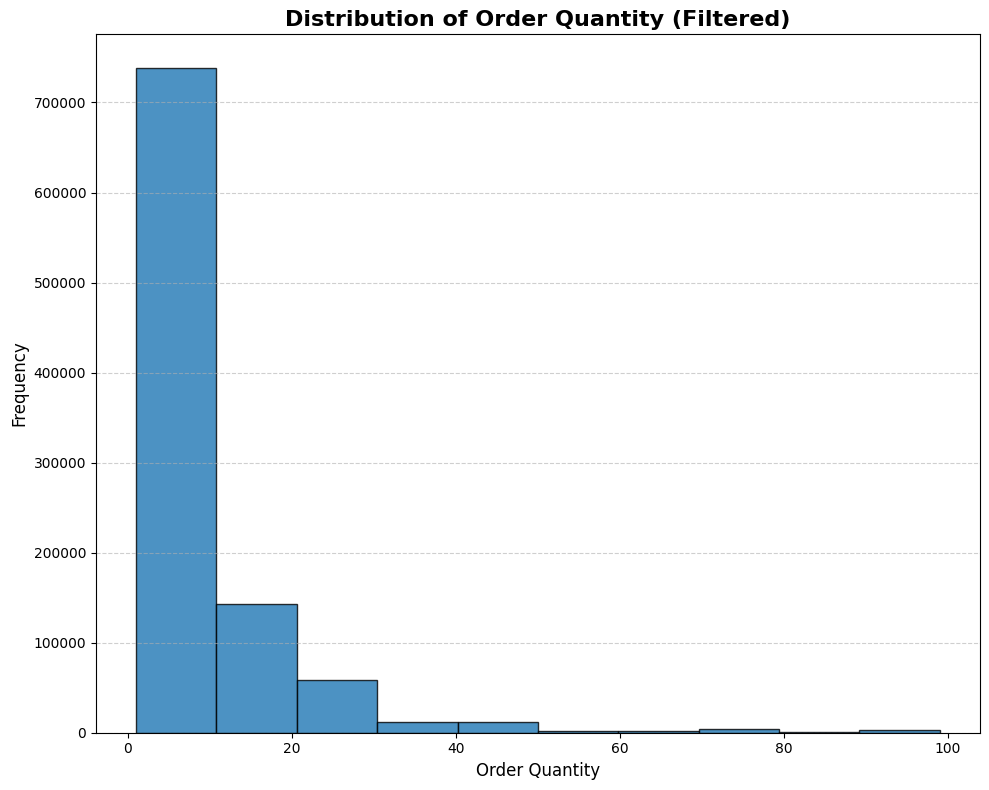

In [117]:
# ploting the histogram of the quantity to check which frequency often get saled
plt.figure(figsize=(10,8))

plt.hist(
    Retail_orders["Quantity"],
    bins=10,
    edgecolor="black",
    alpha=0.8
)

plt.title("Distribution of Order Quantity (Filtered)", fontsize=16, fontweight="bold")
plt.xlabel("Order Quantity", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("Order_Quantity.png",bbox_inches="tight")
plt.show()

### Customer Pareto Analysis

In [118]:
# pareto analysis for find the 20% customer generates the 80% revenue
Customer_pareto_analysis = sales_date.groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False)
Customer_pareto_analysis.head()

Customer ID
18102.0    569501.50
14646.0    516874.50
14156.0    313437.62
14911.0    285118.84
17450.0    244784.25
Name: Revenue, dtype: float64

In [119]:
# reseting the index and nameing the 2 column as "Revenue"
Customer_pareto_analysis = Customer_pareto_analysis.reset_index(name="Revenue")


In [120]:
Customer_pareto_analysis.columns

Index(['Customer ID', 'Revenue'], dtype='object')

In [121]:
# Addding the column fo cumulative cumsum of the revenue and nameing it as Cumulative_revenue
Customer_pareto_analysis["Cumulative_revenue"] = Customer_pareto_analysis["Revenue"].cumsum()
# Creating the column fo the cumulative_percentage using the sum of revenue and cumalative_revenue
Customer_pareto_analysis["Cumulative_revenue_per"] = (
    Customer_pareto_analysis["Cumulative_revenue"]/
    (Customer_pareto_analysis["Revenue"]).sum()
)*100

In [122]:
#Creating the rank column which helps in ploting the cutomer wise revenue analysis
Customer_pareto_analysis["Rank"] = Customer_pareto_analysis["Revenue"].rank(ascending=False).astype(int)

In [123]:
Customer_pareto_analysis.head()

,Customer ID,Revenue,Cumulative_revenue,Cumulative_revenue_per,Rank
0,18102.0,569501.50,569501.50,3.358523,1
1,14646.0,516874.50,1086376.00,6.406690,2
2,14156.0,313437.62,1399813.62,8.255126,3
3,14911.0,285118.84,1684932.46,9.936559,4
4,17450.0,244784.25,1929716.71,11.380126,5


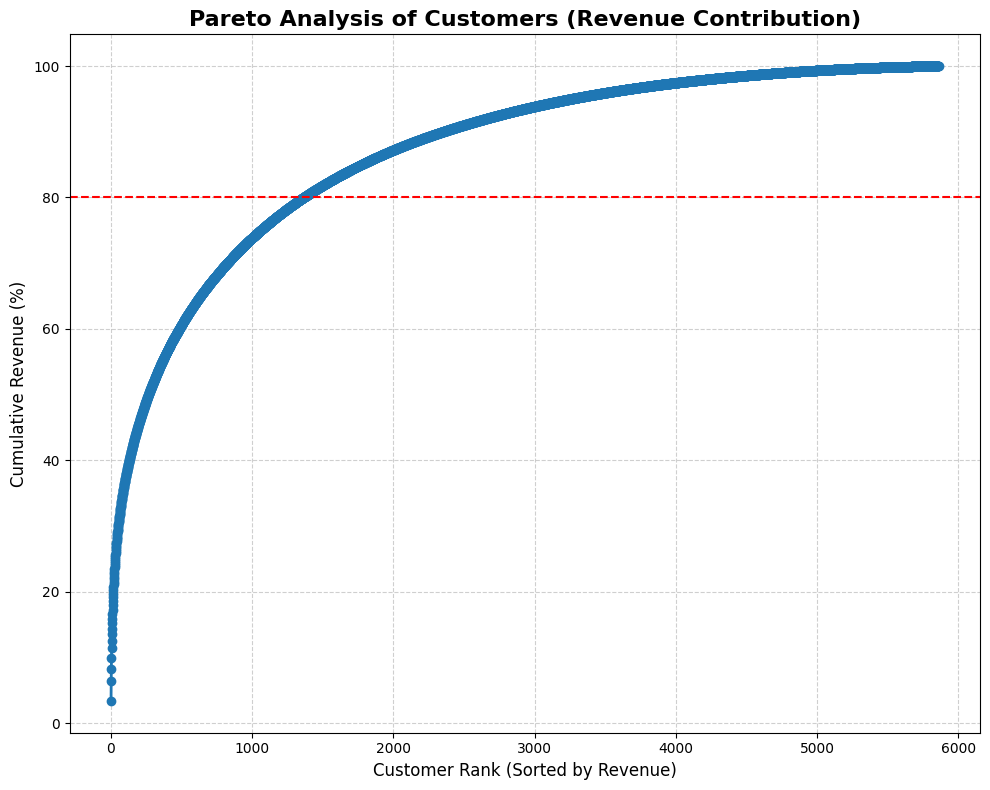

In [124]:
# ploting the perero analysis for the cutomer wise revenue
plt.figure(figsize=(10,8))

plt.plot(
    Customer_pareto_analysis["Rank"],
    Customer_pareto_analysis["Cumulative_revenue_per"],
    marker="o",
    linewidth=2
)

plt.axhline(y=80, color="red", linestyle="--")

plt.title("Pareto Analysis of Customers (Revenue Contribution)", fontsize=16, fontweight="bold")
plt.xlabel("Customer Rank (Sorted by Revenue)", fontsize=12)
plt.ylabel("Cumulative Revenue (%)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("customer_pareto.png",bbox_inches="tight")

plt.show()

### Quantity vs Revenue Analysis

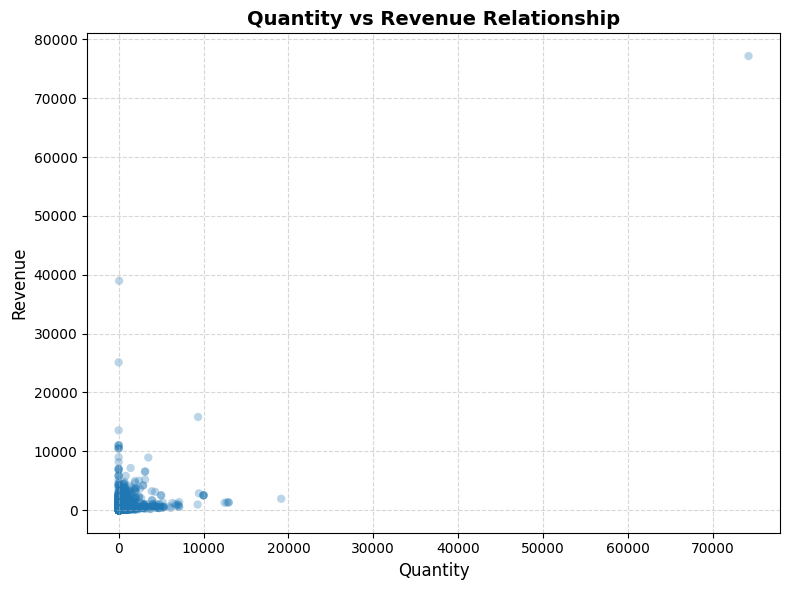

In [125]:
# checking the relation between the quantity vs revenue
plt.figure(figsize=(8,6))

plt.scatter(
    sales_date["Quantity"],
    sales_date["Revenue"],
    alpha=0.3,
    edgecolors="none"
)

plt.title("Quantity vs Revenue Relationship", fontsize=14, fontweight="bold")
plt.xlabel("Quantity", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("Quant_vs_Reven.png",bbox_inches="tight")

plt.show()

### Price vs Revenue Analysis

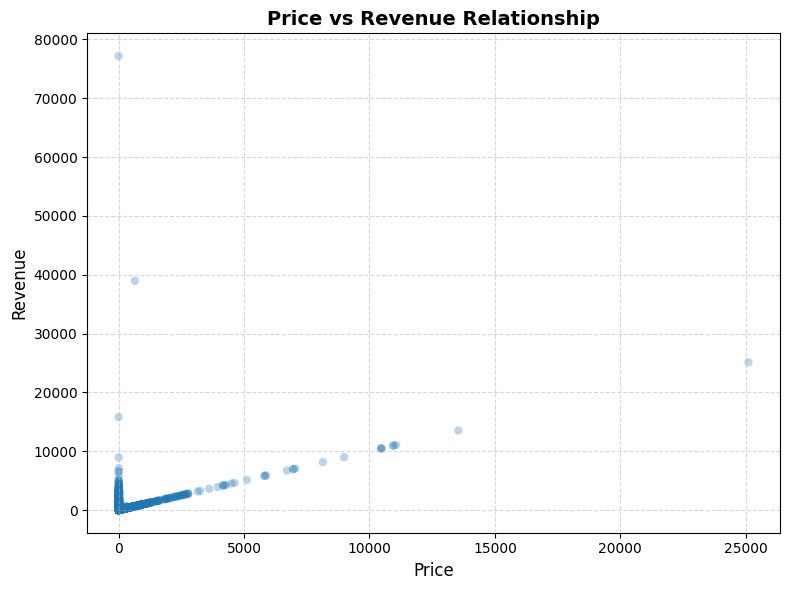

In [126]:
# checking the relation between the quantity and revenue
plt.figure(figsize=(8,6))

plt.scatter(
    sales_date["Price"],
    sales_date["Revenue"],
    alpha=0.3,
    edgecolors="none"
)

plt.title("Price vs Revenue Relationship", fontsize=14, fontweight="bold")
plt.xlabel("Price", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("Price_vs_Reven.png",bbox_inches="tight")

plt.show()

### Correlation Analysis

### Insight

- Revenue is more strongly correlated with quantity than price.
- This suggests that increasing sales volume drives revenue more than pricing.

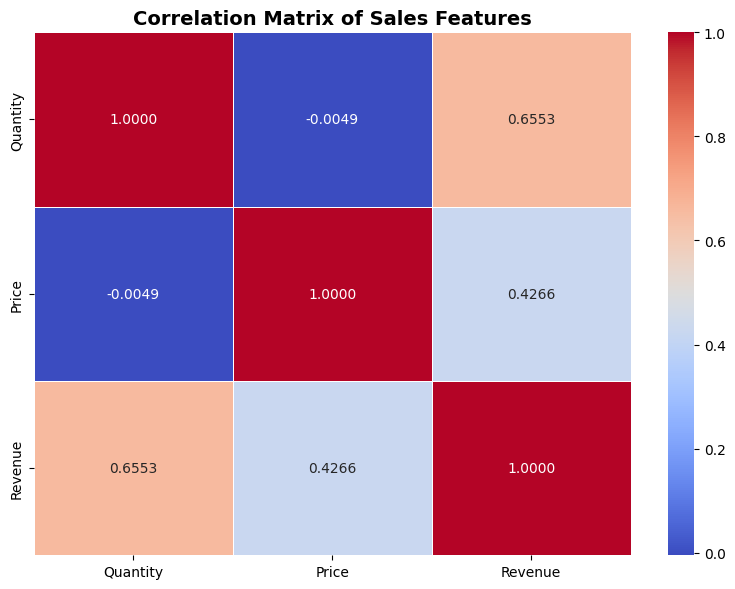

In [127]:
# Finding the relation between the quantity , price and revenue
plt.figure(figsize=(8,6))

corr_matrix = sales_date[["Quantity","Price","Revenue"]].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".4f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Sales Features", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("Corelation_matrix.png",bbox_inches="tight")

plt.show()

## Customer Segmentation using RFM

### Insight

- A large portion of customers are classified as lost.
- A smaller group of loyal and champion customers contribute significantly to revenue.
- Retention strategies are critical for long-term growth.o

### Create Snapshot Date

In [128]:
# creating the snapshot for find the max and next of the max date so that helps in the finding rfm
snapshot =sales_date["InvoiceDate"].max()+pd.Timedelta(days=1)
snapshot

Timestamp('2011-12-05 13:15:00')

### Build RFM Table

In [129]:
# grouping the customer id by invoicedate where snap - invoicedate , customer with n of unique orders and sum of revenue to customer id 
rfm = sales_date.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
})

In [130]:
# renaming the columns invoicedate to recency , invoice to frequency and revenue to Monetary
rfm.columns = ["Recency","Frequency","Monetary"]
rfm

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,321,12,77556.46
12347.0,35,7,4696.71
12348.0,71,5,2019.40
12349.0,14,4,4428.69
12350.0,305,1,334.40
...,...,...,...
18283.0,5,21,2456.90
18284.0,427,1,461.68
18285.0,656,1,427.00


### Assign RFM Scores

In [131]:
# For reading purpose divding the coulumsn like ratings 
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"],
    5,
    labels=[1,2,3,4],
    duplicates="drop"
)
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])


### Generate RFM Score

In [132]:
# combining all the scores and it's helps to identifiy
rfm["RFM_Score"] = (rfm["R_Score"].astype(str) +
                    rfm["F_Score"].astype(str)+
                    rfm["R_Score"].astype(str))

In [133]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,321,12,77556.46,2,4,5,242
12347.0,35,7,4696.71,4,3,5,434
12348.0,71,5,2019.40,3,3,4,333
12349.0,14,4,4428.69,5,2,5,525
12350.0,305,1,334.40,2,1,2,212


### Customer Segmentation Rules

In [134]:
# providing the segment based on the rfm score 
def segment_customer(row):
    if row["R_Score"]>=4 and row["F_Score"]>=4:
        return "Champions"
    if row["R_Score"]>=3 and row["F_Score"]>=3:
        return "Loyal Customers"
    if row["R_Score"]>=4 and row["F_Score"]<=2:
        return "New Customer"
    if row["R_Score"]<=2 and row["F_Score"]>=3:
        return "At risk"
    else :
        return "Lost Customer"
rfm["Segments"] = rfm.apply(segment_customer,axis=1)

### Segment Distribution

In [135]:
# checking the segment and it's unique counts 
rfm["Segments"].value_counts()

Segments
Lost Customer      2754
Loyal Customers     980
New Customer        979
Champions           861
At risk             286
Name: count, dtype: int64

## Key Insights

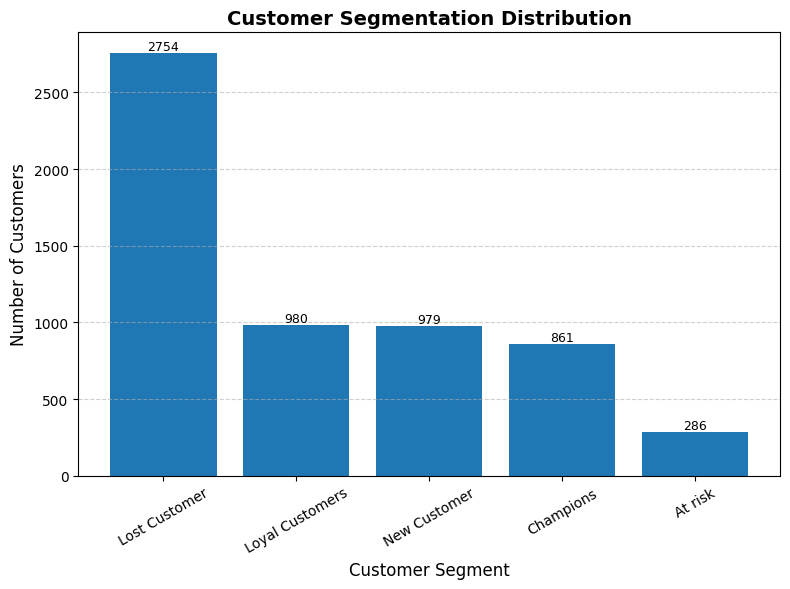

In [136]:
# ploting the segment by creting the segment_counts and with bar plt
plt.figure(figsize=(8,6))

segment_counts = rfm["Segments"].value_counts().sort_values(ascending=False)

bars = plt.bar(segment_counts.index, segment_counts.values)

plt.title("Customer Segmentation Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Add labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        int(yval),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("rfm_segments.png",bbox_inches="tight")

plt.show()

## Key Business Insights

- Sales peak in November indicating strong seasonal demand
- A small number of products drive most revenue
- High-value customers contribute significantly to total sales
- UK dominates revenue but international markets show higher AOV
- Most purchases are small (1–5 items)
- Revenue is driven more by quantity than price

## Business Recommendations

1. Re-engage inactive customers using targeted campaigns
2. Increase inventory before peak season (Q4)
3. Focus on retaining high-value customers
4. Explore wholesale opportunities for bulk buyers

## Conclusion

This analysis of the Online Retail dataset reveals key patterns in customer behavior, product performance, and revenue distribution.

The business is highly dependent on a small group of high-value customers and top-performing products, as observed through the Pareto analysis. A significant portion of revenue is generated by a limited number of customers and products, indicating strong opportunities for targeted marketing and retention strategies.

Seasonal trends show that sales peak toward the end of the year, suggesting that demand increases during specific periods. This highlights the importance of inventory planning and promotional campaigns during high-demand months.

Country-wise analysis indicates that a few regions contribute the majority of revenue, while others have lower but potentially growing engagement. Filtering countries with a minimum number of orders provided a more reliable comparison of average order value, improving decision-making accuracy.

Customer segmentation using the RFM model shows a clear distribution of Champions, Loyal Customers, At-Risk, and Lost Customers. This segmentation enables the business to apply personalized strategies, such as rewarding high-value customers, re-engaging inactive users, and converting new customers into repeat buyers.

Overall, the analysis provides actionable insights that can help improve customer retention, optimize inventory management, and increase revenue through data-driven decision-making.